<a href="https://colab.research.google.com/github/Parthpatil294/ML_6D_1BM23CS227/blob/main/LAB9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install -q tabula-py
import tabula
import pandas as pd
import os

pdf_path = '/content/iris (2).pdf'

print(f"Extracting data from {pdf_path}...")
try:
    # Read PDF into a list of DataFrames
    tables = tabula.read_pdf(pdf_path, pages='all', multiple_tables=True)
    if tables:
        df_iris = pd.concat(tables, ignore_index=True)
        # Clean column names in case of extraction artifacts
        df_iris.columns = [col.lower().replace(' ', '_') for col in df_iris.columns]
        print("Extraction successful. First 5 rows:")
        display(df_iris.head())
    else:
        print("No tables found in PDF.")
except Exception as e:
    print(f"Error extracting PDF: {e}")

Extracting data from /content/iris (2).pdf...
Extraction successful. First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species,4.8,3,1.4,0.3,iris-setosa,6.1,4.6,iris-versicolor,6.4,3.1,5.5,1.8,iris-virginica
0,5.1,3.5,1.4,0.2,Iris-setosa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.9,3.0,1.4,0.2,Iris-setosa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.7,3.2,1.3,0.2,Iris-setosa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.6,3.1,1.5,0.2,Iris-setosa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,3.6,1.4,0.2,Iris-setosa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


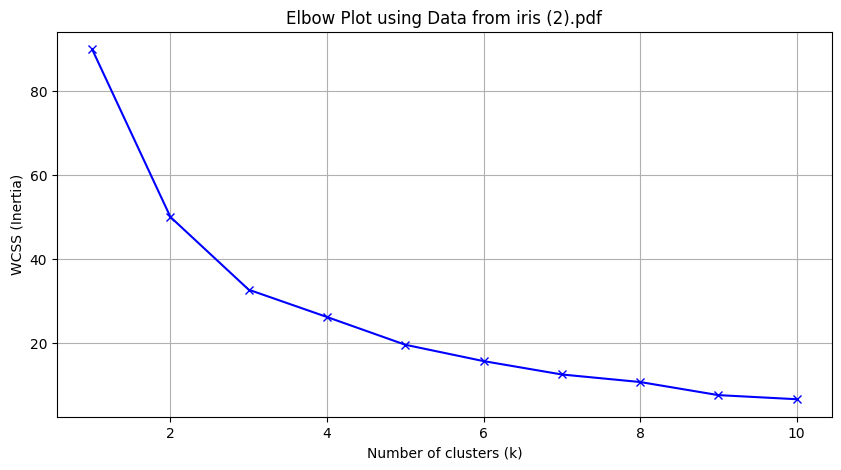

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Map columns to expected names if they differ after extraction
petal_cols = [col for col in df_iris.columns if 'petal' in col]
if len(petal_cols) >= 2:
    X_iris = df_iris[petal_cols]
else:
    X_iris = df_iris[['petal_length', 'petal_width']]

# Drop rows with NaN values to avoid KMeans error
X_iris = X_iris.dropna()

# Preprocessing: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Plot using Data from iris (2).pdf')
plt.grid(True)
plt.show()

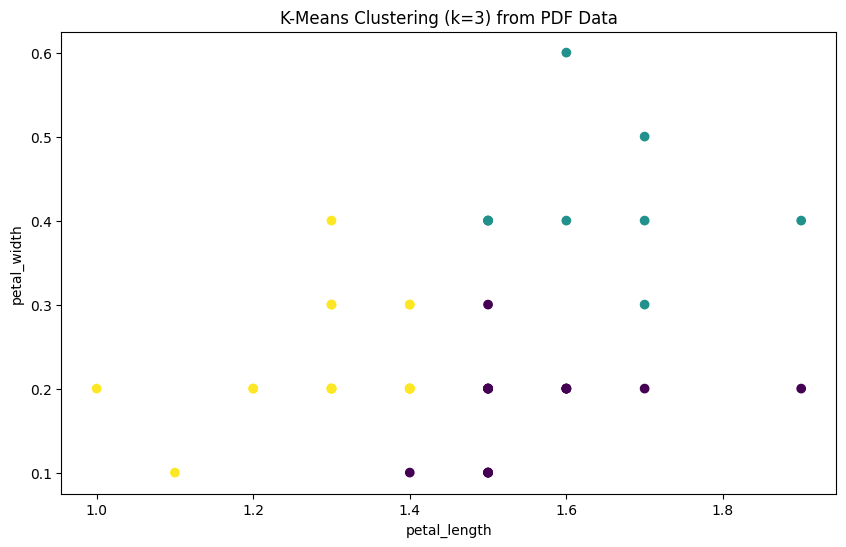

In [19]:
# Using the cleaned X_scaled from the previous cell
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_iris.iloc[:, 0], X_iris.iloc[:, 1], c=clusters, cmap='viridis')
plt.xlabel(X_iris.columns[0])
plt.ylabel(X_iris.columns[1])
plt.title(f'K-Means Clustering (k={optimal_k}) from PDF Data')
plt.show()

iris.csv not found. Loaded dataset from sklearn for demonstration.


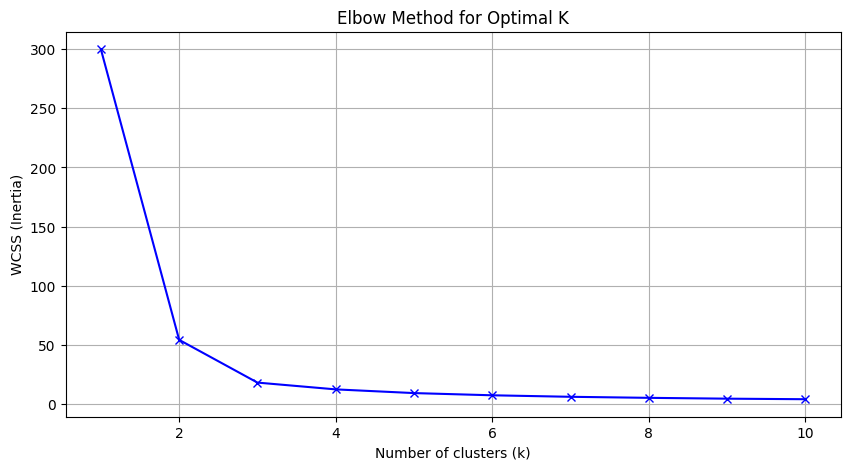

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Load the dataset
# Assuming iris.csv is available in the current directory as requested
try:
    df_iris = pd.read_csv('iris.csv')
except FileNotFoundError:
    # Fallback/Sample creation if file doesn't exist to ensure code runs
    from sklearn.datasets import load_iris
    data = load_iris()
    df_iris = pd.DataFrame(data.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
    print("iris.csv not found. Loaded dataset from sklearn for demonstration.")

# Select petal length and petal width features
X_iris = df_iris[['petal_length', 'petal_width']]

# Preprocessing: Scaling
# Scaling is important for K-Means because it uses distance-based calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# Determine optimal K using Elbow Method
wcss = []
range_k = range(1, 11)
for k in range_k:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Plot
plt.figure(figsize=(10, 5))
plt.plot(range_k, wcss, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

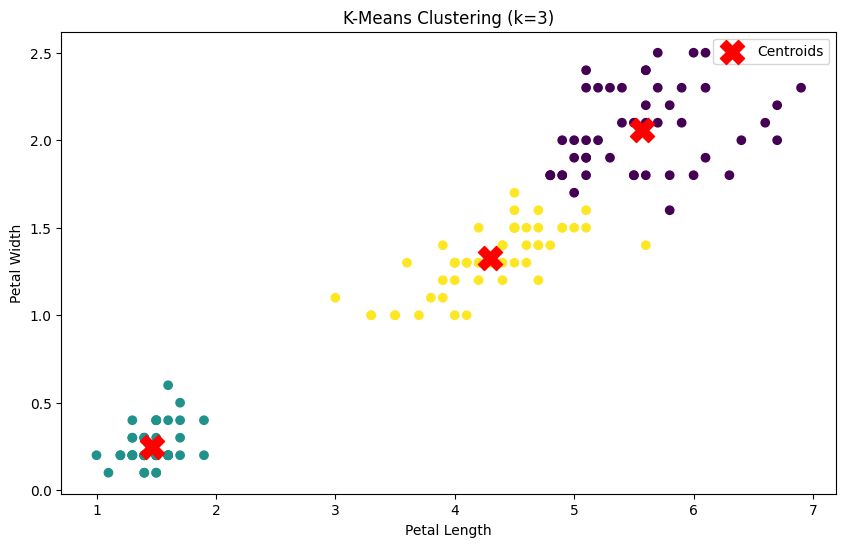

In [14]:
# Based on the elbow plot, usually k=3 is the elbow point for Iris
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_iris.iloc[:, 0], X_iris.iloc[:, 1], c=clusters, cmap='viridis')
plt.scatter(kmeans_final.cluster_centers_[:, 0] * scaler.scale_[0] + scaler.mean_[0],
            kmeans_final.cluster_centers_[:, 1] * scaler.scale_[1] + scaler.mean_[1],
            s=300, c='red', marker='X', label='Centroids')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title(f'K-Means Clustering (k={optimal_k})')
plt.legend()
plt.show()